In [3]:
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import torch
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

## Initial Setup

In [4]:
RUN_ID = 'test1'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

VARIABLES = ['R0','R1', 'C1', 'k', 'sdot', 'Ue']
# Optimization settings for PySR
SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


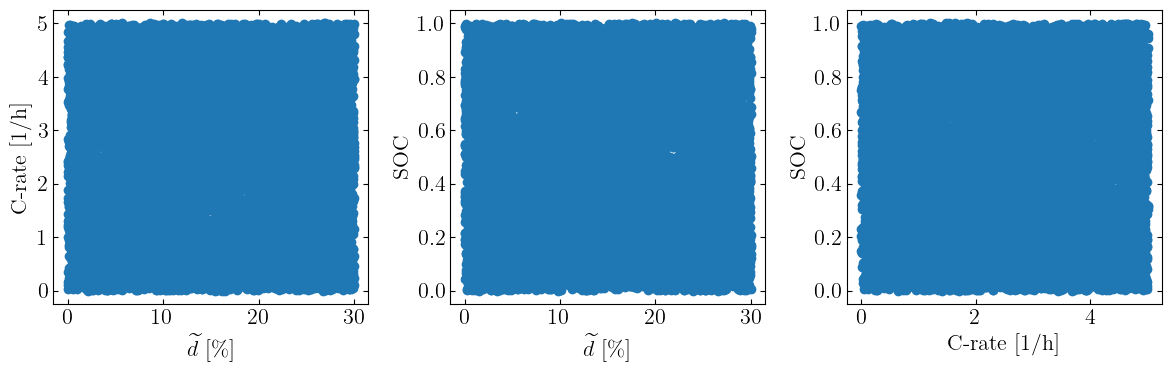

In [5]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')

f, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[0].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[0].set_ylabel('C-rate [1/h]')
ax[1].set_xlabel('C-rate [1/h]')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[1].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[1].set_ylabel('SOC ')
ax[2].plot(df['C_rate'],df['SOC'], 'o')
ax[2].set_xlabel('C-rate [1/h]')
ax[2].set_ylabel('SOC ')
plt.tight_layout()

#display(df)
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)


In [6]:

s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)

s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']].copy()
REF_VALUES['s'] = s_data['s'].max()

s_data['C'] = s_data['I'] * 3600 / Q0


s_data['s'] = s_data['s'] / REF_VALUES['s']

s_data['C'] = s_data['C'] / REF_VALUES['C']

s_data['u_per'] = s_data['u_per'] / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'] / REF_VALUES['sdot']
s_data.describe()



,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


In [7]:
# Save reference values for simulating the observed outputs. 

save_refvalues = True
if save_refvalues:
    df_ref = pd.DataFrame(REF_VALUES, index=[0])
    df_existing = pd.read_csv("saved_sr_models/ref_values.csv")
    if RUN_ID in df_existing['run_id'].values:
        print(f'Run ID {RUN_ID} already exists in ref_values.csv. Did not save new reference values.')
    else:
        df_ref.to_csv(f'saved_sr_models/ref_values_{RUN_ID}.csv', index=False)
        df_ref['run_id'] = RUN_ID
        df_new = pd.DataFrame(df_ref, columns=df_existing.columns.values)
        df_combined = pd.concat([df_existing,df_new], ignore_index=True)
        df_combined.to_csv("saved_sr_models/ref_values.csv", index=False)

        #df_combined.to_excel("exp_log/Euler_exps.xlsx", index=False)

Run ID test1 already exists in ref_values.csv. Did not save new reference values.


In [8]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


In [9]:
samples = generate_data(df.values)

100%|██████████| 10000/10000 [00:08<00:00, 1164.40it/s]


In [10]:
VARIABLES = ['R0','R1', 'C1', 'k']
N_VAR = len(VARIABLES)
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']

data.describe() 

,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


# Importing data

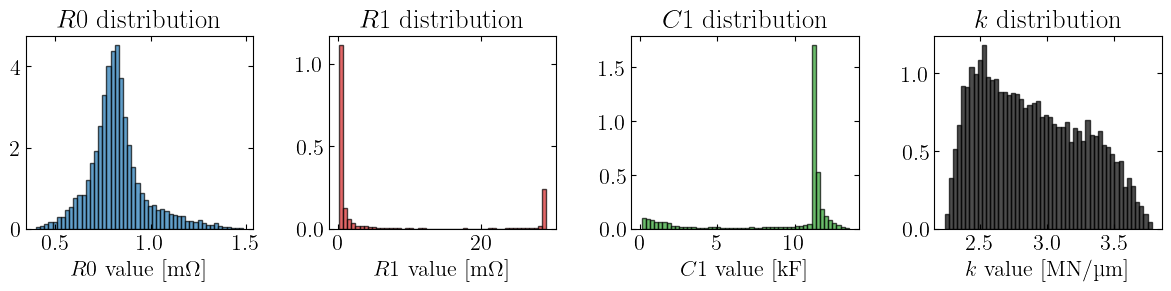

In [11]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [12]:
def get_XY(d_frame, s_frame = None):

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

In [13]:
split_train = int(len(data) * 0.99)
s_split_train = int(len(s_data) * 0.99)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]


X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    'sdot':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    'sdot':  Ys_test
}



# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280976
Equation: 0.823641

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.0149950655
Equation: soc ^ soc

Model 3: Complexity=5, Loss=0.009113719
Equation: sqrt(cube(soc) + 0.46438357)

Model 4: Complexity=6, Loss=0.006578302
Equation: sqrt(square(cube(soc)) + 0.5578389)

Model 5: Complexity=9, Loss=0.00576369
Equation: sqrt((cube(soc) + 0.8635916) / (C + 1.1838646))

Model 6: Complexity=10, Loss=0.0055404245
Equation: sqrt(sqrt(cube(soc) + (0.21728562 / (C + 0.38458228))))

Model 7: Complexity=11, Loss=0.0054049953
Equation: square(sqrt((cube(soc) + 1.3961607) / sqrt(C + 3.4583414)))

Model 8: Complexity=12, Loss=0.004622262
Equation: sqrt((0.8635916 / square((C * d) + 1.1838646)) + cube(soc))

Model 9: Complexity=14, Loss=0.004056845
Equation: sqrt(square(sqrt((cube(soc) + 0.67791325) / sqrt(C + sqrt(exp(d))))))

Model 10: Complexity=15, Loss=0.0035378325
Equation: sqrt(sqrt(cube(((0.41851413 ^ d) ^ C)

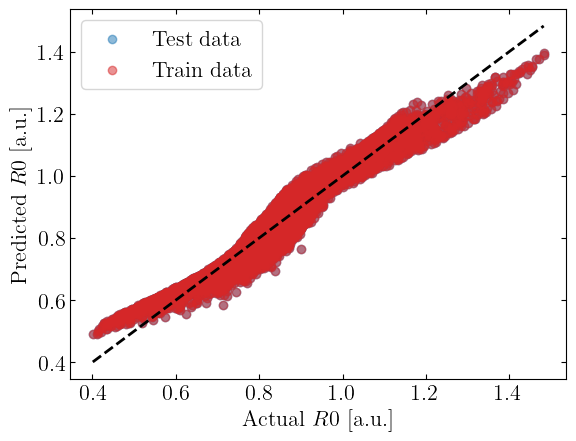

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(log(sqrt(exp(-d + (soc**4 + sqrt(0.4619381**C))**2) + exp(sqrt(soc**(2*C))))))
Loss: 0.0014862021
Best model complexity: 26


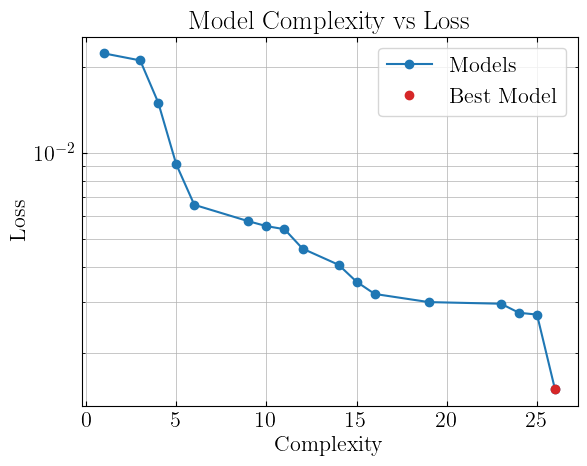

In [14]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21213
Equation: 5.6810527

Model 1: Complexity=3, Loss=97.50852
Equation: C * 10.939657

Model 2: Complexity=4, Loss=72.184326
Equation: cube(2.3945594 - soc)

Model 3: Complexity=5, Loss=40.808723
Equation: exp(cube(1.5339174 - soc))

Model 4: Complexity=6, Loss=37.75937
Equation: cube((soc * -4.425492) + 3.1350992)

Model 5: Complexity=8, Loss=36.106464
Equation: cube((soc * -4.425492) + 3.1350992) + C

Model 6: Complexity=9, Loss=25.585371
Equation: exp(C) * ((1.589618 - soc) ^ 6.0609417)

Model 7: Complexity=10, Loss=25.107788
Equation: cube(((2.4043963 - soc) + (C - soc)) - soc)

Model 8: Complexity=11, Loss=24.700047
Equation: (((1.5811733 - soc) ^ 6.548868) * exp(C)) - 1.0324343

Model 9: Complexity=12, Loss=21.17035
Equation: cube(((C - soc) + (2.5772004 - (soc + soc))) - soc)

Model 10: Complexity=14, Loss=20.3435
Equation: square((((1.7749001 - soc) - soc) + sqrt(C)) - soc) ^ 1.928053

Model 11: Complexity=15, Loss=3.2375164
Equation: sqrt(exp(

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 29.6484515560277*sqrt(exp(-1322.84031474933*soc**6/(C + 0.021994349)**6))
Loss: 3.2375164
Best model complexity: 15


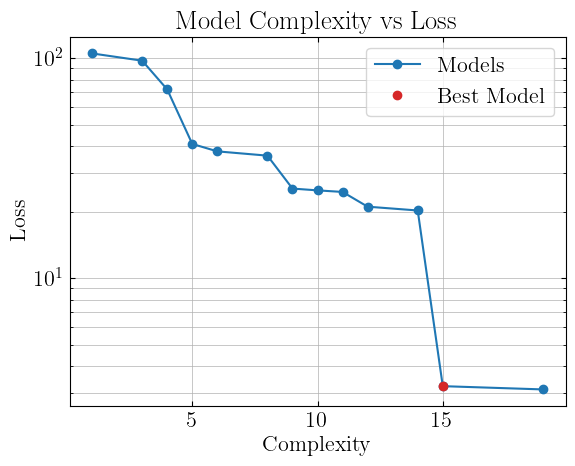

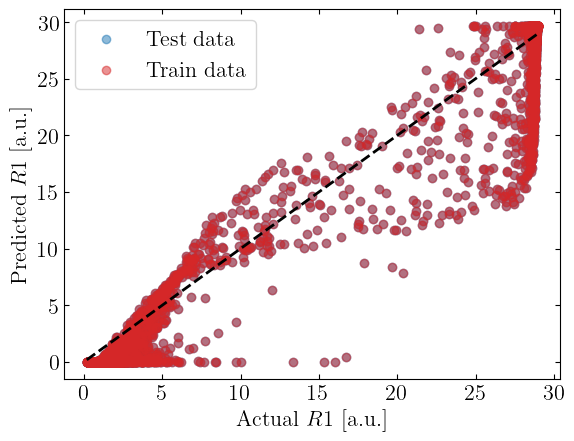

In [15]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735358
Equation: 9.444992

Model 1: Complexity=3, Loss=13.298216
Equation: soc + 8.961584

Model 2: Complexity=4, Loss=5.710617
Equation: sqrt(soc) * 14.145032

Model 3: Complexity=6, Loss=5.612623
Equation: sqrt(soc / 0.0059944238) - -0.8213004

Model 4: Complexity=7, Loss=3.6012406
Equation: cube(2.2968454 - (0.0030632631 ^ soc))

Model 5: Complexity=9, Loss=3.2277036
Equation: cube(2.2968454 - (0.0030632631 ^ soc)) - C

Model 6: Complexity=11, Loss=3.0898898
Equation: cube((2.122474 - (0.0030632631 ^ soc)) + 0.24945506) + -1.6222277

Model 7: Complexity=12, Loss=3.0705042
Equation: soc + cube(2.2161238 - cube((C * 0.19710329) ^ soc))

Model 8: Complexity=13, Loss=1.7779278
Equation: cube(2.2586298 - cube(((0.008577676 ^ soc) * C) ^ soc))

Model 9: Complexity=17, Loss=1.4336319
Equation: cube((0.1251648 - square(square(cube(((C * 0.23112127) ^ soc) ^ soc)))) + 2.1328106)

Model 10: Complexity=18, Loss=1.2873636
Equation: cube(2.2677283 - cube(((((C * 0.

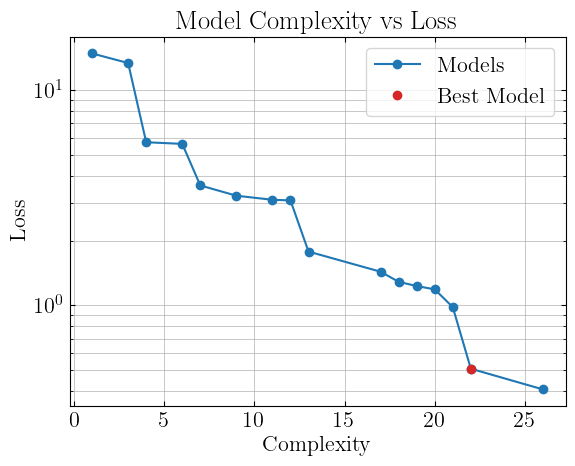

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (2.4137201 - ((0.26815173**(2*soc)*C)**soc)**(24*soc))**3 - 2.558528
Loss: 0.509355
Best model complexity: 22


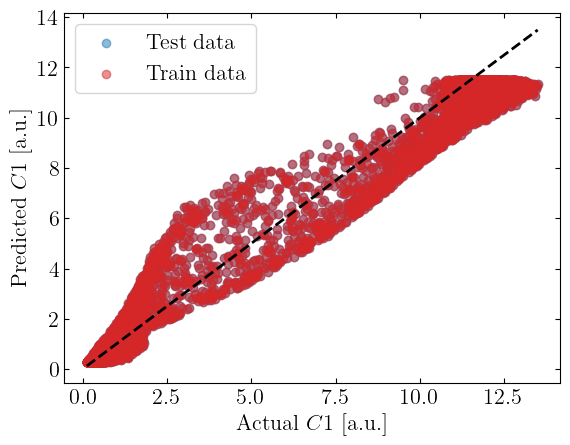

In [16]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.142429
Equation: 2.8875558

Model 1: Complexity=3, Loss=0.015178897
Equation: d + 2.3876803

Model 2: Complexity=5, Loss=0.0094130365
Equation: (d * 1.2569067) + 2.2556307

Model 3: Complexity=6, Loss=0.007912861
Equation: exp(d * 0.82353234) + 1.3337358

Model 4: Complexity=7, Loss=0.007826416
Equation: ((soc * -0.2900135) + 2.5320399) + d

Model 5: Complexity=8, Loss=0.007671361
Equation: (square(d) + (soc / -3.4098816)) + 2.7013283

Model 6: Complexity=9, Loss=0.002379942
Equation: 2.25404 - (d * (-3.3477108 / (soc + 2.165235)))

Model 7: Complexity=13, Loss=0.001052161
Equation: 2.3237023 - ((d * -2.6866481) / ((soc / (d + 0.1703901)) + 1.7937753))

Model 8: Complexity=14, Loss=5.8949234e-05
Equation: (C + 1.4349741) + (exp((d * 0.8828686) - (soc * 0.20406175)) - C)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -C + C + exp(d*0.8828686 - 0.20406175*soc) + 1.4349741
Loss: 5.8949234e-05
Best model complexity: 14


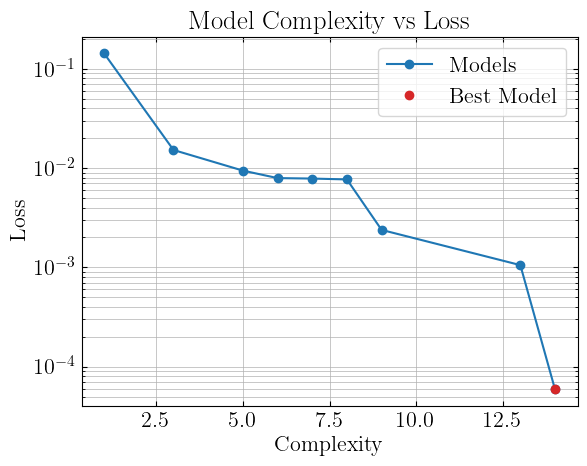

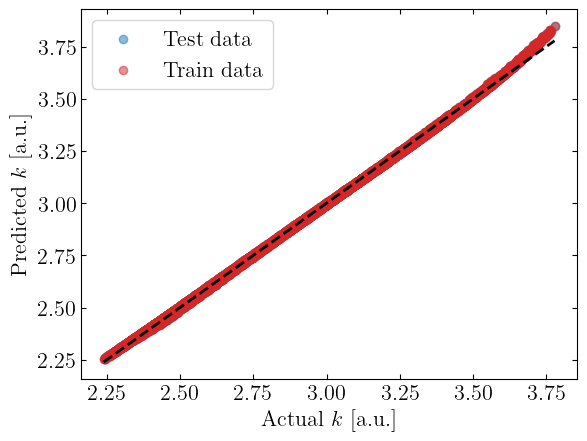

In [17]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element sdot: ['C', 'd', 'soc', 's']
Running symbolic regression for element sdot with run_id sdot_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0071614
Equation: C

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38231918
Equation: C * 3.0191102

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.17696713
Equation: C / (d - -0.16678987)

Model 5: Complexity=6, Loss=0.04342255
Equation: C * square(d + -2.1781814)

Model 6: Complexity=8, Loss=0.01306428
Equation: C * (square(d + -2.7359002) + -2.2658026)

Model 7: Complexity=9, Loss=0.011686952
Equation: square((cube(d) + -2.2875001) + d) * C

Model 8: Complexity=10, Loss=0.009406843
Equation: (exp(-2.0882356 * (d * d)) * C) / 0.20220795

Model 9: Complexity=11, Loss=0.008727901
Equation: (1.2151319 - ((d + -0.9075438) + d)) * (C / 0.40809494)

Model 10: Complexity=13, Loss=0.00839462
Equation: ((((d + 3.3242192) - (d / 0.24081746)) / 0.6534212) * C) - -0.037245836

Model 11: Complexity=14, Loss=0.007931285
Equation: (C / 0.68806624) * (3.4991865 - ((d + (d + d)) ^ 1.10573

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C*(1.2151319 - (d + d - 0.9075438))/0.40809494
Loss: 0.008727901
Best model complexity: 11


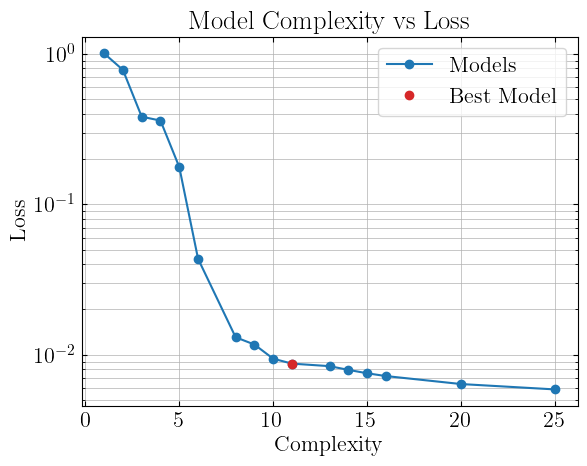

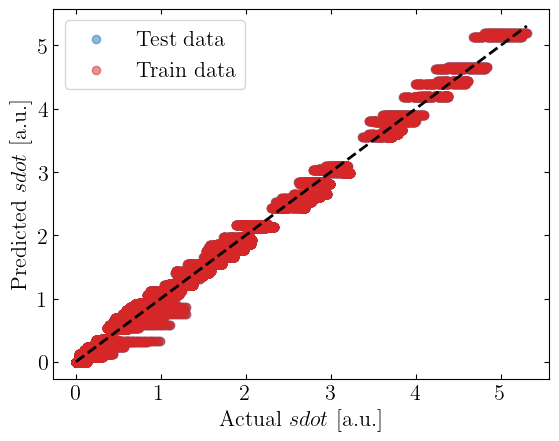

In [18]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f'sdot_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'sdot')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('sdot',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [19]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [20]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f'sdot_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f'sdot_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)